# Experiment 7: Comparing Descriptions Across MS COCO Thematic Categories

Analyze model bias by comparing caption quality across different object categories to identify which classes the model performs best and worst on.

In [4]:
import json
import torch
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter, defaultdict
from contextlib import contextmanager

sys.path.insert(0, os.path.abspath('..'))
from caption import caption_image_beam_search
import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Workaround for Adam optimizer unpickling issue
@contextmanager
def patch_torch_optim():
    """Temporarily patch torch.optim classes to skip problematic state deserialization."""
    original_setstate = {}
    try:
        def noop_setstate(self, state):
            pass
        
        original_setstate['Adam'] = torch.optim.Adam.__setstate__
        original_setstate['SGD'] = torch.optim.SGD.__setstate__
        torch.optim.Adam.__setstate__ = noop_setstate
        torch.optim.SGD.__setstate__ = noop_setstate
        
        yield
    finally:
        for name, method in original_setstate.items():
            getattr(torch.optim, name).__setstate__ = method

# Load model with optimizer patching
with patch_torch_optim():
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=True)
    except Exception:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=False)

decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

with open(WORDMAP_PATH, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

# Define COCO categories
COCO_CATEGORIES = {
    'person': ['person', 'people', 'man', 'woman', 'child', 'boy', 'girl'],
    'animal': ['dog', 'cat', 'bird', 'horse', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'sheep'],
    'food': ['apple', 'orange', 'banana', 'pizza', 'donut', 'cake', 'sandwich', 'broccoli', 'carrot'],
    'vehicle': ['car', 'truck', 'bus', 'train', 'airplane', 'bicycle', 'motorcycle', 'boat'],
    'indoor': ['chair', 'couch', 'bed', 'table', 'toilet', 'tv', 'laptop', 'refrigerator', 'sink']
}

# Build reference captions
references = {}
for img in dataset['images']:
    if img['split'] in {'val', 'test'}:
        references[img['filename']] = [[token for token in sent['tokens']] for sent in img['sentences']]

print("Data loaded. Categories:", list(COCO_CATEGORIES.keys()))

/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'models.Encoder' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1

Data loaded. Categories: ['person', 'animal', 'food', 'vehicle', 'indoor']


In [5]:
def detect_category(caption_tokens):
    """Detect dominant category in a list of caption tokens."""
    caption_lower = [t.lower() for t in caption_tokens]
    
    for category, keywords in COCO_CATEGORIES.items():
        for keyword in keywords:
            if keyword in caption_lower:
                return category
    return 'other'

# Select images by category - manually categorize by looking at reference captions
category_images = defaultdict(list)

for filename, refs in list(references.items())[:200]:
    # Flatten reference tokens
    all_tokens = []
    for ref in refs:
        all_tokens.extend(ref)
    
    category = detect_category(all_tokens)
    if category != 'other':
        category_images[category].append(filename)
    
    # Limit to 20 per category
    if all(len(imgs) >= 20 for imgs in category_images.values()):
        break

# Trim to 20 each
for cat in category_images:
    category_images[cat] = category_images[cat][:20]

print("Images per category:")
for cat, imgs in category_images.items():
    print(f"  {cat}: {len(imgs)} images")

# Generate captions and evaluate
results = []

print(f"\nGenerating captions by category...")

with torch.no_grad():
    for category, filenames in sorted(category_images.items()):
        print(f"  Processing {category}...")
        
        for filename in filenames:
            fpath = os.path.join('../dataset/val2014', filename)
            if not os.path.exists(fpath):
                continue
            
            try:
                seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, 5)
                hyp = [rev_word_map[i] for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
                
                ref_captions = references[filename]
                smoother = SmoothingFunction().method1
                bleu = sentence_bleu(ref_captions, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
                
                results.append({
                    'category': category,
                    'filename': filename,
                    'bleu_4': bleu,
                    'caption': ' '.join(hyp)
                })
            except:
                continue

df_categories = pd.DataFrame(results)
print(f"Completed evaluation of {len(df_categories)} images")

Images per category:
  person: 20 images
  indoor: 20 images
  vehicle: 16 images
  animal: 20 images
  food: 10 images

Generating captions by category...
  Processing animal...
  Processing food...
  Processing indoor...
  Processing person...
  Processing vehicle...
Completed evaluation of 86 images



=== BLEU-4 Performance by Category ===
            mean     std     min     max  count
category                                       
animal    0.3430  0.2447  0.0474  0.7477     20
food      0.2237  0.1593  0.0616  0.6389     10
indoor    0.2203  0.1995  0.0285  0.7176     20
person    0.2791  0.2943  0.0298  0.8801     20
vehicle   0.1969  0.2275  0.0316  0.7260     16


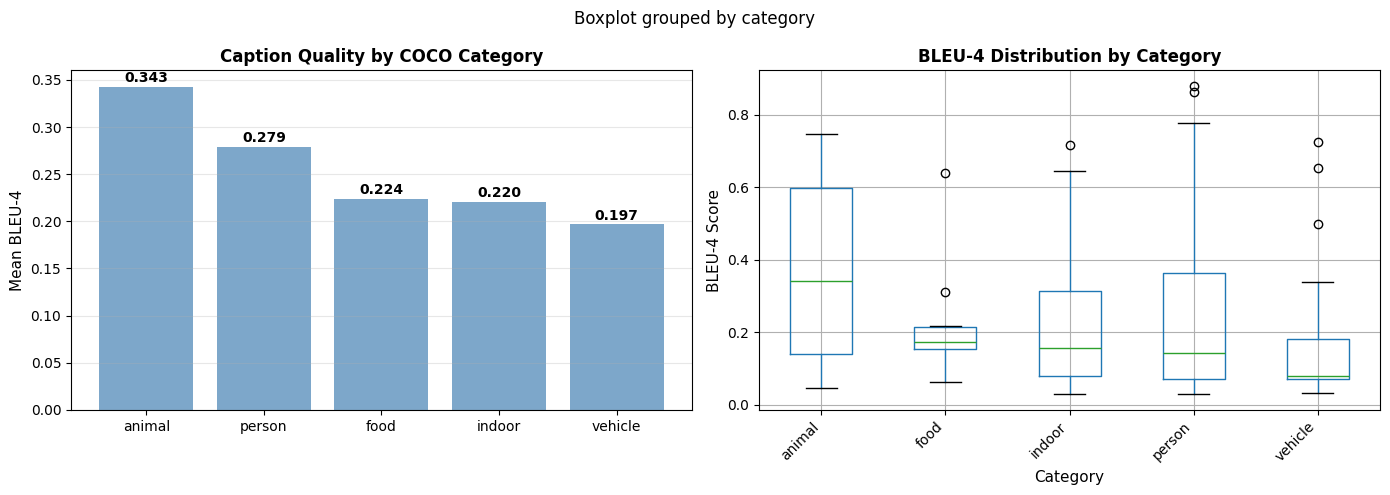


Model Performance Insights:
  Best performance: animal (0.3430)
  Worst performance: vehicle (0.1969)
  Performance gap: 0.1461


In [6]:
# Analyze by category
print("\n=== BLEU-4 Performance by Category ===")
category_stats = df_categories.groupby('category')['bleu_4'].agg(['mean', 'std', 'min', 'max', 'count'])
print(category_stats.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of mean BLEU by category
cat_means = df_categories.groupby('category')['bleu_4'].mean().sort_values(ascending=False)
axes[0].bar(cat_means.index, cat_means.values, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Mean BLEU-4', fontsize=11)
axes[0].set_title('Caption Quality by COCO Category', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(cat_means.values):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Box plot
df_categories.boxplot(column='bleu_4', by='category', ax=axes[1])
axes[1].set_ylabel('BLEU-4 Score', fontsize=11)
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_title('BLEU-4 Distribution by Category', fontsize=12, fontweight='bold')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Find model biases
print("\nModel Performance Insights:")
best_cat = cat_means.idxmax()
worst_cat = cat_means.idxmin()
print(f"  Best performance: {best_cat} ({cat_means[best_cat]:.4f})")
print(f"  Worst performance: {worst_cat} ({cat_means[worst_cat]:.4f})")
print(f"  Performance gap: {(cat_means[best_cat] - cat_means[worst_cat]):.4f}")